In [23]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
 
from sklearn.preprocessing import MinMaxScaler


In [24]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [25]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [26]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [27]:
# Check null values in D3
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [28]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [29]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [30]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [31]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [32]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [33]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [34]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [35]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [36]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [37]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [38]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Standardization for Clustering

In [39]:
original_X = X.copy()

In [40]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
scaler = MinMaxScaler()  
X_numeric_std = scaler.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

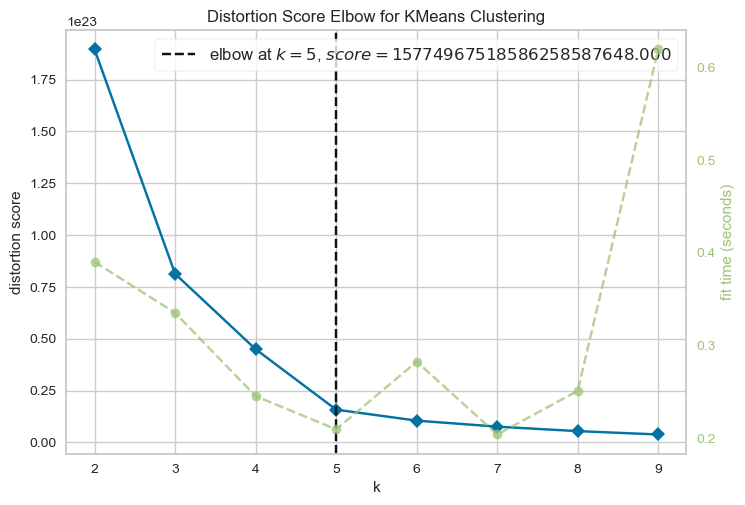

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [41]:
# How many clusters to form - 1. Using elbow method 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [42]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: uicc8_III-IV
Correlation coefficient: 0.25148576790741356


1
Most correlated column: hypopharynx
Correlation coefficient: 0.10259618392242767


2
Most correlated column: hpv_related
Correlation coefficient: 0.2460640183505367


3
Most correlated column: female
Correlation coefficient: 0.17850067771869405


4
Most correlated column: glcm_Autocorrelation_d_1_CT_c16
Correlation coefficient: 0.05627117308757032




In [43]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [44]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = MinMaxScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [45]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [46]:
X_new

,uicc8_III-IV,hypopharynx,hpv_related,female,glcm_Autocorrelation_d_1_CT_c16
0,0.0,0,0.0,1,94.224171
1,0.0,0,0.0,0,119.164361
2,1.0,0,0.0,0,116.129599
3,0.0,0,0.0,0,164.460301
4,0.0,0,0.0,0,210.184151
...,...,...,...,...,...
134,0.0,0,1.0,0,170.013539
135,1.0,0,1.0,0,80.363559
136,0.0,0,1.0,0,119.378154
137,1.0,0,1.0,0,197.371851


In [47]:
X_new_std

,uicc8_III-IV,hypopharynx,hpv_related,female,glcm_Autocorrelation_d_1_CT_c16
0,0.0,0,0.0,1,0.358521
1,0.0,0,0.0,0,0.461358
2,1.0,0,0.0,0,0.448845
3,0.0,0,0.0,0,0.648129
4,0.0,0,0.0,0,0.836665
...,...,...,...,...,...
134,0.0,0,1.0,0,0.671027
135,1.0,0,1.0,0,0.301369
136,0.0,0,1.0,0,0.462240
137,1.0,0,1.0,0,0.783835


In [48]:
MAASTRO_new

,uicc8_III-IV,hypopharynx,hpv_related,female,glcm_Autocorrelation_d_1_CT_c16
0,0,0,1,0,192.231457
1,1,0,0,0,97.043711
2,1,0,0,0,189.006881
3,1,0,0,1,89.769620
4,0,0,1,0,112.952004
...,...,...,...,...,...
94,1,0,0,1,48.979926
95,1,0,0,0,171.978518
96,1,0,1,0,197.769903
97,0,0,1,0,103.710049


In [49]:
MAASTRO_new_std

,uicc8_III-IV,hypopharynx,hpv_related,female,glcm_Autocorrelation_d_1_CT_c16
0,0,0,1,0,0.762640
1,1,0,0,0,0.370147
2,1,0,0,0,0.749344
3,1,0,0,1,0.340153
4,0,0,1,0,0.435743
...,...,...,...,...,...
94,1,0,0,1,0.171963
95,1,0,0,0,0.679130
96,1,0,1,0,0.785477
97,0,0,1,0,0.397635


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [50]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 13:56:22,420] A new study created in memory with name: no-name-c5014839-55c7-4609-905f-90a790a492c0


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7056277056277056
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8185654008438819


[I 2024-04-17 13:56:22,903] A new study created in memory with name: no-name-fd278712-a92d-4f74-9d6f-8c5b0ca2be28


Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 13:56:22,896] Trial 0 finished with value: 0.75019458057944 and parameters: {}. Best is trial 0 with value: 0.75019458057944.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.75019458057944], datetime_start=datetime.datetime(2024, 4, 17, 13, 56, 22, 498405), datetime_complete=datetime.datetime(2024, 4, 17, 13, 56, 22, 895974), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.75019458057944


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.16033404459549605
Fold 2 IBS: 0.2018472365261542
Fold 3 IBS: 0.14243487398310004
Fold 4 IBS: 0.15845134390133403
Fold 5 IBS: 0.25170865515662444
[I 2024-04-17 13:56:23,314] Trial 0 finished with value: 0.18295523083254175 and parameters: {}. Best is trial 0 with value: 0.18295523083254175.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18295523083254175], datetime_start=datetime.datetime(2024, 4, 17, 13, 56, 22, 944663), datetime_complete=datetime.datetime(2024, 4, 17, 13, 56, 23, 313786), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18295523083254175


In [51]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [52]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.75
train_ibs:  0.183


#### Test

In [53]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [54]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.548
IBS score: 0.243


In [55]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [56]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [57]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 13:56:23,558] A new study created in memory with name: no-name-c36d7c95-532f-4e13-867d-8a90e83a53ac


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7424242424242424


[I 2024-04-17 13:56:23,791] A new study created in memory with name: no-name-2a29a34e-3c01-410a-b94b-9b8ae86b18a5


Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6150234741784038
[I 2024-04-17 13:56:23,785] Trial 0 finished with value: 0.7268586529897133 and parameters: {}. Best is trial 0 with value: 0.7268586529897133.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7268586529897133], datetime_start=datetime.datetime(2024, 4, 17, 13, 56, 23, 589961), datetime_complete=datetime.datetime(2024, 4, 17, 13, 56, 23, 785103), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7268586529897133


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2139765177749073
Fold 2 IBS: 0.2215779141699564
Fold 3 IBS: 0.20453594224963634
Fold 4 IBS: 0.22473803445955803
Fold 5 IBS: 0.2181243143679756
[I 2024-04-17 13:56:24,486] Trial 0 finished with value: 0.21659054460440674 and parameters: {}. Best is trial 0 with value: 0.21659054460440674.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054460440674], datetime_start=datetime.datetime(2024, 4, 17, 13, 56, 23, 831006), datetime_complete=datetime.datetime(2024, 4, 17, 13, 56, 24, 486264), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054460440674


In [58]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [59]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.727
train_ibs:  0.217


#### Test

In [60]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [61]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.593


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [62]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [63]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 13:56:24,824] A new study created in memory with name: no-name-844010b8-e72d-46bc-9b29-e905459eaa8b


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7056277056277056
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8333333333333334


[I 2024-04-17 13:56:25,431] A new study created in memory with name: no-name-ce8e6c70-bfa9-4ce8-bb67-fb100af669cd


Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 13:56:25,418] Trial 0 finished with value: 0.7511749727363027 and parameters: {}. Best is trial 0 with value: 0.7511749727363027.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7511749727363027], datetime_start=datetime.datetime(2024, 4, 17, 13, 56, 24, 888587), datetime_complete=datetime.datetime(2024, 4, 17, 13, 56, 25, 417944), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7511749727363027


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.16033589174033339
Fold 2 IBS: 0.20236974372859332
Fold 3 IBS: 0.1439520415279143
Fold 4 IBS: 0.15819646471284288
Fold 5 IBS: 0.25037504321235665
[I 2024-04-17 13:56:26,064] Trial 0 finished with value: 0.18304583698440807 and parameters: {}. Best is trial 0 with value: 0.18304583698440807.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18304583698440807], datetime_start=datetime.datetime(2024, 4, 17, 13, 56, 25, 467783), datetime_complete=datetime.datetime(2024, 4, 17, 13, 56, 26, 64089), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18304583698440807


In [64]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [65]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.751
train_ibs:  0.183


#### Test

In [66]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [67]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.548


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.241


In [68]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [69]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 13:56:26,532] A new study created in memory with name: no-name-9a740521-474b-4f46-836e-bff299662044


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7056277056277056
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 13:56:27,207] Trial 0 finished with value: 0.7511749727363027 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.7511749727363027.
Fold 1 C-index: 0.7056277056277056
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 13:56:27,887] Trial 1 finished with value: 0.7511749727363027 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.7511749727363027.
Fold 1 C-index: 0.7056277056277056
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 13:56:28,466] Trial 2 finished with value: 0.7511749727363027 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 1 C-index: 0.7056277056277056
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 13:56:39,082] Trial 24 finished with value: 0.7511749727363027 and parameters: {'l1_ratio': 0.35784592664527676}. Best is trial 11 with value: 0.7560026345259899.
Fold 1 C-index: 0.7056277056277056
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 13:56:39,536] Trial 25 finished with value: 0.7511749727363027 and parameters: {'l1_ratio': 0.8277117787416304}. Best is trial 11 with value: 0.7560026345259899.
Fold 1 C-index: 0.7056277056277056
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 13:56:39,944] Trial 26 finished with value: 0.7511749727363027 and parameters: {'l1_ratio': 0.56218220394271

Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 13:56:50,466] Trial 48 finished with value: 0.7550222423691272 and parameters: {'l1_ratio': 0.03747893503780727}. Best is trial 11 with value: 0.7560026345259899.
Fold 1 C-index: 0.7056277056277056
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 13:56:51,032] Trial 49 finished with value: 0.75019458057944 and parameters: {'l1_ratio': 0.060120734661776365}. Best is trial 11 with value: 0.7560026345259899.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6572769953051644
[I 2024-04-17 13:56:51,477] Trial 50 finished with value: 0.7550222423691272 and parameters: {'l1_ratio': 0.03795750511613392}. Best is trial 11 with value: 

...

Fold 1 IBS: 0.1599963462329786
Fold 2 IBS: 0.20217117734235007
Fold 3 IBS: 0.14398280799754914
Fold 4 IBS: 0.15816997862278065
Fold 5 IBS: 0.2501812350104489
[I 2024-04-17 13:57:14,694] Trial 0 finished with value: 0.18290030904122148 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.18290030904122148.
Fold 1 IBS: 0.15952015544540152
Fold 2 IBS: 0.20176269719962794
Fold 3 IBS: 0.1440643253226439
Fold 4 IBS: 0.15809523995251817
Fold 5 IBS: 0.2498215703232209
[I 2024-04-17 13:57:15,236] Trial 1 finished with value: 0.18265279764868247 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.18265279764868247.
Fold 1 IBS: 0.15949104081160514
Fold 2 IBS: 0.2017022227924713
Fold 3 IBS: 0.1441149393181919
Fold 4 IBS: 0.15807959624239776
Fold 5 IBS: 0.2496978506503173
[I 2024-04-17 13:57:15,814] Trial 2 finished with value: 0.18261712996299667 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.1826171299629966

Fold 1 IBS: 0.1593273919735979
Fold 2 IBS: 0.20151392366473464
Fold 3 IBS: 0.1440530458352749
Fold 4 IBS: 0.15807847056319962
Fold 5 IBS: 0.24958857299277454
[I 2024-04-17 13:57:28,098] Trial 25 finished with value: 0.18251228100591632 and parameters: {'l1_ratio': 0.06766854141508033}. Best is trial 18 with value: 0.18250725498898002.
Fold 1 IBS: 0.2133407196233815
Fold 2 IBS: 0.22112010719766323
Fold 3 IBS: 0.20376496080277096
Fold 4 IBS: 0.2236816090525974
Fold 5 IBS: 0.21799166407846013
[I 2024-04-17 13:57:28,336] Trial 26 finished with value: 0.21597981215097461 and parameters: {'l1_ratio': 0.015423757551295547}. Best is trial 18 with value: 0.18250725498898002.
Fold 1 IBS: 0.1598772199844666
Fold 2 IBS: 0.20205777706575864
Fold 3 IBS: 0.14407627812350757
Fold 4 IBS: 0.1581460299091611
Fold 5 IBS: 0.24997331726105185
[I 2024-04-17 13:57:28,794] Trial 27 finished with value: 0.18282612446878915 and parameters: {'l1_ratio': 0.58416616744615}. Best is trial 18 with value: 0.1825072549

Fold 5 IBS: 0.24972738148170204
[I 2024-04-17 13:57:41,171] Trial 49 finished with value: 0.18257488446199216 and parameters: {'l1_ratio': 0.12475215536814217}. Best is trial 18 with value: 0.18250725498898002.
Fold 1 IBS: 0.1598650943180919
Fold 2 IBS: 0.2020410624640612
Fold 3 IBS: 0.14399550011870574
Fold 4 IBS: 0.15813175121462658
Fold 5 IBS: 0.2500257932144191
[I 2024-04-17 13:57:41,690] Trial 50 finished with value: 0.1828118402659809 and parameters: {'l1_ratio': 0.556147470734502}. Best is trial 18 with value: 0.18250725498898002.
Fold 1 IBS: 0.15935823089474482
Fold 2 IBS: 0.20154877141181204
Fold 3 IBS: 0.1440651185984574
Fold 4 IBS: 0.15807850631407847
Fold 5 IBS: 0.24960887047126723
[I 2024-04-17 13:57:42,298] Trial 51 finished with value: 0.18253189953807197 and parameters: {'l1_ratio': 0.09816171051292913}. Best is trial 18 with value: 0.18250725498898002.
Fold 1 IBS: 0.15941101420157106
Fold 2 IBS: 0.20163557261106865
Fold 3 IBS: 0.1441293331381206
Fold 4 IBS: 0.158071130

Fold 2 IBS: 0.20155002712612843
Fold 3 IBS: 0.1441618305095457
Fold 4 IBS: 0.15805717292765542
Fold 5 IBS: 0.24966380419572143
[I 2024-04-17 13:57:55,270] Trial 74 finished with value: 0.1825461175018281 and parameters: {'l1_ratio': 0.09224761727188636}. Best is trial 18 with value: 0.18250725498898002.
Fold 1 IBS: 0.15927812587942253
Fold 2 IBS: 0.20151812494438362
Fold 3 IBS: 0.1441198583476421
Fold 4 IBS: 0.1580631428073179
Fold 5 IBS: 0.24967452757300715
[I 2024-04-17 13:57:55,974] Trial 75 finished with value: 0.18253075591035467 and parameters: {'l1_ratio': 0.058948978116146786}. Best is trial 18 with value: 0.18250725498898002.
Fold 1 IBS: 0.15931411143260682
Fold 2 IBS: 0.2015001623329755
Fold 3 IBS: 0.14405123768778302
Fold 4 IBS: 0.22102430158144615
Fold 5 IBS: 0.24957737090705542
[I 2024-04-17 13:57:56,518] Trial 76 finished with value: 0.19509343678837338 and parameters: {'l1_ratio': 0.05608153299462483}. Best is trial 18 with value: 0.18250725498898002.
Fold 1 IBS: 0.15938

Fold 1 IBS: 0.15939404525213982
Fold 2 IBS: 0.20164620212787956
Fold 3 IBS: 0.14404035640184412
Fold 4 IBS: 0.15809069964633868
Fold 5 IBS: 0.24972952597103185
[I 2024-04-17 13:58:09,399] Trial 99 finished with value: 0.1825801658798468 and parameters: {'l1_ratio': 0.17778308561161432}. Best is trial 92 with value: 0.18250094351178317.


* Best trial for IBS: 
 FrozenTrial(number=92, state=TrialState.COMPLETE, values=[0.18250094351178317], datetime_start=datetime.datetime(2024, 4, 17, 13, 58, 4, 906815), datetime_complete=datetime.datetime(2024, 4, 17, 13, 58, 5, 536064), params={'l1_ratio': 0.06058949003990009}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=92, value=None)


* Best Score for IBS: 
 0.18250094351178317


In [70]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [71]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.756
train_ibs:  0.183


#### Test

In [72]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [73]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.046971505265140434)

test_cindex : 0.549


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.06058949003990009)

test_ibs:  0.241


In [74]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [75]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 13:58:09,889] A new study created in memory with name: no-name-94111aca-db87-40ea-918f-e8d93d2fd00a


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7012987012987013
Fold 2 C-index: 0.7209821428571429
Fold 3 C-index: 0.8308823529411765
Fold 4 C-index: 0.8417721518987342
Fold 5 C-index: 0.6173708920187794
[I 2024-04-17 13:58:13,988] Trial 0 finished with value: 0.7424612482029069 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.7424612482029069.
Fold 1 C-index: 0.7380952380952381
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.8406862745098039
Fold 4 C-index: 0.8459915611814346
Fold 5 C-index: 0.596244131455399
[I 2024-04-17 13:58:16,945] Trial 1 finished with value: 0.7461677267626609 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, '

Fold 5 C-index: 0.6291079812206573
[I 2024-04-17 13:58:57,037] Trial 15 finished with value: 0.7563883194811822 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 1, 'n_estimators': 170, 'oob_score': True, 'max_samples': 0.8107341403225247, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.16866630138034366, 'warm_start': True}. Best is trial 14 with value: 0.7589606199779058.
Fold 1 C-index: 0.7034632034632035
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8553921568627451
Fold 4 C-index: 0.8333333333333334
Fold 5 C-index: 0.6267605633802817
[I 2024-04-17 13:58:57,896] Trial 16 finished with value: 0.7520041371221986 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 17, 'min_samples_leaf': 1, 'max_depth': 1, 'n_estimators': 122, 'oob_score': True, 'max_samples': 0.8029947290400248, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.16939069998793121, 'warm_start': True}. Best is trial 14 with value: 0.75896061997790

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.8725490196078431
Fold 4 C-index: 0.8544303797468354
Fold 5 C-index: 0.6619718309859155
[I 2024-04-17 13:59:10,794] Trial 30 finished with value: 0.7847707655486383 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 19, 'min_samples_leaf': 8, 'max_depth': 5, 'n_estimators': 87, 'oob_score': True, 'max_samples': 0.8560618314784392, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.05171778435676043, 'warm_start': True}. Best is trial 30 with value: 0.7847707655486383.
Fold 1 C-index: 0.7337662337662337
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.8725490196078431
Fold 4 C-index: 0.8459915611814346
Fold 5 C-index: 0.6619718309859155
[I 2024-04-17 13:59:11,586] Trial 31 finished with value: 0.783570014822571 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 19, 'min_samples_leaf': 8, 'max_depth': 5, 'n_estimators': 88, 'oob_score': True, 'max_samples': 0.8811778881728696, 

...

Fold 1 IBS: 0.179739472639964
Fold 2 IBS: 0.20655963739802444
Fold 3 IBS: 0.1603540804804018
Fold 4 IBS: 0.15164530271716853
Fold 5 IBS: 0.23683667387692378
[I 2024-04-17 14:02:31,727] Trial 32 finished with value: 0.1870270334224965 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 19, 'min_samples_leaf': 5, 'max_depth': 3, 'n_estimators': 430, 'oob_score': False, 'max_samples': 0.4835022710812676, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.002155379148304812}. Best is trial 24 with value: 0.1835709736129117.
Fold 1 IBS: 0.1790576167267212
Fold 2 IBS: 0.20399309494407902
Fold 3 IBS: 0.16186161070671579
Fold 4 IBS: 0.15492747170795043
Fold 5 IBS: 0.23462866641875998
[I 2024-04-17 14:02:40,841] Trial 33 finished with value: 0.1868936921008453 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 17, 'min_samples_leaf': 2, 'max_depth': 5, 'n_estimators': 475, 'oob_score': False, 'max_samples': 0.37387983615525405, 'max_features': 'auto', 'min_weight_fraction_leaf

Fold 1 IBS: 0.21396611630308587
Fold 2 IBS: 0.22128578499137064
Fold 3 IBS: 0.20494763385500975
Fold 4 IBS: 0.22458864636052045
Fold 5 IBS: 0.21835632746820222
[I 2024-04-17 14:04:10,530] Trial 48 finished with value: 0.21662890179563776 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 7, 'min_samples_leaf': 3, 'max_depth': 8, 'n_estimators': 458, 'oob_score': False, 'max_samples': 0.3922325503608847, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.44962767788541247}. Best is trial 24 with value: 0.1835709736129117.
Fold 1 IBS: 0.17796563775674165
Fold 2 IBS: 0.20370174644994637
Fold 3 IBS: 0.171517868595724
Fold 4 IBS: 0.17148297209794164
Fold 5 IBS: 0.223775911859169
[I 2024-04-17 14:04:14,470] Trial 49 finished with value: 0.1896888273519045 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 20, 'min_samples_leaf': 7, 'max_depth': 1, 'n_estimators': 158, 'oob_score': False, 'max_samples': 0.4811537699409366, 'max_features': 'auto', 'min_weight_fraction_leaf'

Fold 1 IBS: 0.17306609858030478
Fold 2 IBS: 0.20056679378102527
Fold 3 IBS: 0.16483454642708212
Fold 4 IBS: 0.168669248113596
Fold 5 IBS: 0.22211773656718203
[I 2024-04-17 14:06:07,727] Trial 64 finished with value: 0.185850884693838 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 1, 'n_estimators': 307, 'oob_score': False, 'max_samples': 0.61236843448516, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.0006773134961711308}. Best is trial 57 with value: 0.1828527291760214.
Fold 1 IBS: 0.17714990554881124
Fold 2 IBS: 0.20014993030180434
Fold 3 IBS: 0.17119549755262523
Fold 4 IBS: 0.17407979627901463
Fold 5 IBS: 0.2221650358422527
[I 2024-04-17 14:06:13,193] Trial 65 finished with value: 0.1889480331049016 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 17, 'min_samples_leaf': 18, 'max_depth': 2, 'n_estimators': 279, 'oob_score': False, 'max_samples': 0.5564402947049913, 'max_features': 'auto', 'min_weight_fraction_leaf'

Fold 5 IBS: 0.22161455610064004
[I 2024-04-17 14:07:50,769] Trial 79 finished with value: 0.18137429107327666 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 10, 'min_samples_leaf': 1, 'max_depth': 2, 'n_estimators': 296, 'oob_score': False, 'max_samples': 0.5690597268180618, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.0006981102317597312}. Best is trial 75 with value: 0.1812848510189654.
Fold 1 IBS: 0.17346706188319772
Fold 2 IBS: 0.20662348327836494
Fold 3 IBS: 0.1595268150155073
Fold 4 IBS: 0.15412528603535905
Fold 5 IBS: 0.2318664106925289
[I 2024-04-17 14:07:58,055] Trial 80 finished with value: 0.18512181138099157 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 10, 'min_samples_leaf': 1, 'max_depth': 2, 'n_estimators': 262, 'oob_score': False, 'max_samples': 0.5637756064521773, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.04055617282748293}. Best is trial 75 with value: 0.1812848510189654.
Fold 1 IBS: 0.17241867170307612
Fold 2 IBS: 0.200

Fold 1 IBS: 0.1789012036547735
Fold 2 IBS: 0.19906035016773124
Fold 3 IBS: 0.17219922898260834
Fold 4 IBS: 0.1733549599130921
Fold 5 IBS: 0.21974652084850643
[I 2024-04-17 14:09:50,384] Trial 95 finished with value: 0.18865245271334233 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 13, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 269, 'oob_score': True, 'max_samples': 0.5277228550417561, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.2044430572980988}. Best is trial 81 with value: 0.1811651264224968.
Fold 1 IBS: 0.17341521590961026
Fold 2 IBS: 0.20205540296362162
Fold 3 IBS: 0.1669148919781125
Fold 4 IBS: 0.16997833674924584
Fold 5 IBS: 0.22702451000331583
[I 2024-04-17 14:09:55,937] Trial 96 finished with value: 0.18787767152078122 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 3, 'max_depth': 1, 'n_estimators': 243, 'oob_score': False, 'max_samples': 0.6441815441533718, 'max_features': 'log2', 'min_weight_fraction_leaf'

In [76]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [77]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.829
train_ibs:  0.181


#### Test

In [78]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [79]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=18, max_features=None, max_leaf_nodes=9,
                     max_samples=0.9039803085659105, min_samples_leaf=1,
                     min_samples_split=8,
                     min_weight_fraction_leaf=0.05811584068599309,
                     n_estimators=308, random_state=123, warm_start=True)

test_cindex:  0.591


RandomSurvivalForest(max_depth=2, max_features='auto', max_leaf_nodes=11,
                     max_samples=0.5247125563073177, min_samples_leaf=1,
                     min_samples_split=2,
                     min_weight_fraction_leaf=0.004435220380210637,
                     n_estimators=304, random_state=123)

test_ibs:  0.204


In [80]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [81]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 14:10:20,250] A new study created in memory with name: no-name-ad51e609-4f26-4dd2-930f-64f35a951e35


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7359307359307359
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.8382352941176471
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6619718309859155
[I 2024-04-17 14:10:22,036] Trial 0 finished with value: 0.7680345342321762 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7680345342321762.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:10:26,962] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}. Best is 

Fold 3 C-index: 0.8357843137254902
Fold 4 C-index: 0.8354430379746836
Fold 5 C-index: 0.647887323943662
[I 2024-04-17 14:11:22,694] Trial 15 finished with value: 0.759696852877685 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.7711885658248778.
Fold 1 C-index: 0.7294372294372294
Fold 2 C-index: 0.7321428571428571
Fold 3 C-index: 0.8308823529411765
Fold 4 C-index: 0.8164556962025317
Fold 5 C-index: 0.6032863849765259
[I 2024-04-17 14:11:25,473] Trial 16 finished with value: 0.7424409041400641 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_l

Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.8578431372549019
Fold 4 C-index: 0.8417721518987342
Fold 5 C-index: 0.676056338028169
[I 2024-04-17 14:12:08,808] Trial 30 finished with value: 0.7804102994623351 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 16, 'min_samples_leaf': 2, 'max_depth': 11, 'n_estimators': 355, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.8382504072008882, 'min_weight_fraction_leaf': 0.07504341894083728}. Best is trial 23 with value: 0.7821974662569611.
Fold 1 C-index: 0.6926406926406926
Fold 2 C-index: 0.8303571428571429
Fold 3 C-index: 0.8676470588235294
Fold 4 C-index: 0.869198312236287
Fold 5 C-index: 0.7417840375586855
[I 2024-04-17 14:12:11,319] Trial 31 finished with value: 0.8003254488232674 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 20, 'min_samples_leaf': 2, 'max_depth': 11, 'n_estimators': 344, 'oob_score': False, 'warm_start': True, 'max_feature

...

Fold 1 IBS: 0.16622595914562538
Fold 2 IBS: 0.2019787936101078
Fold 3 IBS: 0.1698212064183169
Fold 4 IBS: 0.16300216862739045
Fold 5 IBS: 0.22803742716472658
[I 2024-04-17 14:19:24,443] Trial 30 finished with value: 0.18581311099323342 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 3, 'min_samples_leaf': 6, 'max_depth': 3, 'n_estimators': 454, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.5014558998220808, 'min_weight_fraction_leaf': 0.08899853941230249}. Best is trial 7 with value: 0.18491546179797982.
Fold 1 IBS: 0.1663535002583539
Fold 2 IBS: 0.20212011331928628
Fold 3 IBS: 0.16956880767131755
Fold 4 IBS: 0.16274512626889892
Fold 5 IBS: 0.22853145638644162
[I 2024-04-17 14:19:34,035] Trial 31 finished with value: 0.18586380078085965 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 3, 'n_estimators': 448, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.50

Fold 1 IBS: 0.16616027034681838
Fold 2 IBS: 0.20349026244728588
Fold 3 IBS: 0.1694600650428458
Fold 4 IBS: 0.15937029073261913
Fold 5 IBS: 0.23226475476604255
[I 2024-04-17 14:21:47,471] Trial 45 finished with value: 0.18614912866712235 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 15, 'min_samples_leaf': 10, 'max_depth': 20, 'n_estimators': 483, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.9965944267407703, 'min_weight_fraction_leaf': 0.0038815379899241817}. Best is trial 7 with value: 0.18491546179797982.
Fold 1 IBS: 0.16258213657606624
Fold 2 IBS: 0.20646627469645024
Fold 3 IBS: 0.16946704141225602
Fold 4 IBS: 0.15619789289705294
Fold 5 IBS: 0.23704922726822203
[I 2024-04-17 14:21:53,024] Trial 46 finished with value: 0.1863525145700095 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 19, 'min_samples_leaf': 8, 'max_depth': 19, 'n_estimators': 160, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples

Fold 1 IBS: 0.16989193385366122
Fold 2 IBS: 0.2019819907648291
Fold 3 IBS: 0.1716591798810652
Fold 4 IBS: 0.170017563346221
Fold 5 IBS: 0.22419134283944492
[I 2024-04-17 14:23:54,749] Trial 60 finished with value: 0.1875484021370443 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 16, 'min_samples_leaf': 8, 'max_depth': 14, 'n_estimators': 459, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6847233138776472, 'min_weight_fraction_leaf': 0.20374992385437457}. Best is trial 7 with value: 0.18491546179797982.
Fold 1 IBS: 0.16407903874727917
Fold 2 IBS: 0.20716283345398256
Fold 3 IBS: 0.16692595330732615
Fold 4 IBS: 0.15783525742831456
Fold 5 IBS: 0.233443577904932
[I 2024-04-17 14:24:03,897] Trial 61 finished with value: 0.18588933216836687 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 9, 'min_samples_leaf': 5, 'max_depth': 16, 'n_estimators': 496, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6192

Fold 1 IBS: 0.1643241196929161
Fold 2 IBS: 0.20479349994176965
Fold 3 IBS: 0.1685941327403467
Fold 4 IBS: 0.15821897087175696
Fold 5 IBS: 0.23400166390782412
[I 2024-04-17 14:25:56,969] Trial 75 finished with value: 0.1859864774309227 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 6, 'min_samples_leaf': 6, 'max_depth': 19, 'n_estimators': 470, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.569175138136116, 'min_weight_fraction_leaf': 0.022517095027090858}. Best is trial 7 with value: 0.18491546179797982.
Fold 1 IBS: 0.1734131277161763
Fold 2 IBS: 0.1995846293619731
Fold 3 IBS: 0.17467665339416447
Fold 4 IBS: 0.1739132008162817
Fold 5 IBS: 0.22106000344229934
[I 2024-04-17 14:26:07,786] Trial 76 finished with value: 0.188529522946179 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 8, 'max_depth': 15, 'n_estimators': 485, 'oob_score': False, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.640653

Fold 1 IBS: 0.16231117531549324
Fold 2 IBS: 0.20762015264649775
Fold 3 IBS: 0.16414742277420574
Fold 4 IBS: 0.15548596317088267
Fold 5 IBS: 0.23671324868568053
[I 2024-04-17 14:28:16,713] Trial 90 finished with value: 0.185255592518552 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 8, 'min_samples_leaf': 3, 'max_depth': 20, 'n_estimators': 317, 'oob_score': True, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.581017564530687, 'min_weight_fraction_leaf': 0.011039179726305805}. Best is trial 7 with value: 0.18491546179797982.
Fold 1 IBS: 0.1624625544426354
Fold 2 IBS: 0.20748732260552075
Fold 3 IBS: 0.16409934041979732
Fold 4 IBS: 0.15630515881341886
Fold 5 IBS: 0.23652304516133363
[I 2024-04-17 14:28:24,169] Trial 91 finished with value: 0.1853754842885412 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 8, 'min_samples_leaf': 3, 'max_depth': 20, 'n_estimators': 318, 'oob_score': True, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.5

In [82]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [83]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.813
train_ibs:  0.184


#### Test

In [84]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [85]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=20, max_features=None, max_leaf_nodes=12,
                   max_samples=0.9794591473064957, min_samples_leaf=2,
                   min_samples_split=7,
                   min_weight_fraction_leaf=0.025861888820592756,
                   n_estimators=215, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.531


ExtraSurvivalTrees(max_depth=18, max_features='log2', max_leaf_nodes=6,
                   max_samples=0.5483291729089685, min_samples_leaf=1,
                   min_samples_split=14,
                   min_weight_fraction_leaf=0.0014831447857161974,
                   n_estimators=279, oob_score=True, random_state=123)

IBS: 0.23


In [86]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [87]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 14:29:28,920] A new study created in memory with name: no-name-ffaeac3c-2772-4959-8304-e096a3573bd8


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:30:05,016] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:30:25,959] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:41:11,441] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.7240352060693319.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:42:31,639] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:56:47,214] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.7240352060693319.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.6197183098591549
[I 2024-04-17 14:58:17,063] Trial 26 finished with value: 0.5440329476861168 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446,

...

Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-17 16:43:58,168] Trial 55 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9027683411994925, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.13472529918097312, 'n_estimators': 381, 'criterion': 'squared_error', 'ccp_alpha': 1.3381569877935875, 'min_weight_fraction_leaf': 0.36938177041618503, 'max_features': 'auto', 'min_impurity_decrease': 1.1016843774656315e-07, 'validation_fraction': 0.898549324711475, 'min_samples_split': 3, 'max_leaf_nodes': 12, 'min_samples_leaf': 12, 'max_depth': 3}. Best is trial 53 with value: 0.21497418936819407.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-17 16:45:04,560] Trial 56 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.83247895380525

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-17 16:58:36,644] Trial 66 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9998769156045215, 'learning_rate': 0.010488456761899951, 'dropout_rate': 0.32975112844548055, 'n_estimators': 500, 'criterion': 'squared_error', 'ccp_alpha': 0.7134499429690735, 'min_weight_fraction_leaf': 0.19311178079767077, 'max_features': 'log2', 'min_impurity_decrease': 1.142816958470248e-06, 'validation_fraction': 0.916501041728546, 'min_samples_split': 19, 'max_leaf_nodes': 18, 'min_samples_leaf': 11, 'max_depth': 5}. Best is trial 53 with value: 0.21497418936819407.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-17 16:59:53,279] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.92370310407976

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-17 17:10:54,340] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9372636724132823, 'learning_rate': 0.04128077713454106, 'dropout_rate': 0.2214138929394412, 'n_estimators': 441, 'criterion': 'squared_error', 'ccp_alpha': 0.5872217111247551, 'min_weight_fraction_leaf': 0.2869095730072229, 'max_features': 1, 'min_impurity_decrease': 1.637559261311236e-05, 'validation_fraction': 0.8634632458479912, 'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 8, 'max_depth': 14}. Best is trial 72 with value: 0.2149724780555471.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-17 17:12:21,996] Trial 78 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7443996478445325, 'lear

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-17 17:24:27,675] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5839343488674055, 'learning_rate': 0.005616464421601462, 'dropout_rate': 0.35953503133089737, 'n_estimators': 446, 'criterion': 'squared_error', 'ccp_alpha': 0.3179664432907911, 'min_weight_fraction_leaf': 0.28749157637391265, 'max_features': 'auto', 'min_impurity_decrease': 3.335913971167387e-07, 'validation_fraction': 0.9542099213957375, 'min_samples_split': 6, 'max_leaf_nodes': 20, 'min_samples_leaf': 12, 'max_depth': 1}. Best is trial 72 with value: 0.2149724780555471.
Fold 1 IBS: 0.21342859003514467
Fold 2 IBS: 0.22143629426840983
Fold 3 IBS: 0.20399733386897298
Fold 4 IBS: 0.22406592799361916
Fold 5 IBS: 0.21798750592334298
[I 2024-04-17 17:26:14,767] Trial 89 finished with value: 0.2161831304178979 and parameters: {'subsample': 0.974759756760531

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560957
[I 2024-04-17 17:37:30,861] Trial 99 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.24286963781937687, 'learning_rate': 0.014589250586297647, 'dropout_rate': 0.10216550214025771, 'n_estimators': 399, 'criterion': 'friedman_mse', 'ccp_alpha': 0.7671250956406857, 'min_weight_fraction_leaf': 0.18481046489298308, 'max_features': 'log2', 'min_impurity_decrease': 2.1174148155398794e-07, 'validation_fraction': 0.5826785779285072, 'min_samples_split': 15, 'max_leaf_nodes': 20, 'min_samples_leaf': 15, 'max_depth': 17}. Best is trial 96 with value: 0.2137934314957215.


* Best trial for IBS: 
 FrozenTrial(number=96, state=TrialState.COMPLETE, values=[0.2137934314957215], datetime_start=datetime.datetime(2024, 4, 17, 17, 33, 18, 806205), datetime_complete=datetime.datetime(2024, 4, 17, 17, 34, 38, 322291), params={'subsample': 0.984708728876492, 

In [88]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [89]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.734
train_ibs:  0.214


#### Test

In [90]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [91]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.03063070291051248,
                                 criterion='squared_error',
                                 dropout_rate=0.2576884847115747,
                                 learning_rate=0.007359366951045268,
                                 max_depth=16, max_features=1,
                                 max_leaf_nodes=16,
                                 min_impurity_decrease=1.3903906488794697e-07,
                                 min_samples_leaf=14, min_samples_split=20,
                                 min_weight_fraction_leaf=0.38180626899357545,
                                 n_estimators=96, random_state=123,
                                 subsample=0.8938290428827321,
                                 validation_fraction=0.9577535215137098)

C-index score: 0.631


GradientBoostingSurvivalAnalysis(ccp_alpha=0.03063069674161246,
                                 dropout_rate=0.11706496959585853,
                                 learning_rate=0.020033817173644677,
                                 max_depth=15, max_features='log2',
                                 max_leaf_nodes=19,
                                 min_impurity_decrease=3.628499745047466e-07,
                                 min_samples_leaf=16, min_samples_split=19,
                                 min_weight_fraction_leaf=0.3110347552318222,
                                 n_estimators=439, random_state=123,
                                 subsample=0.984708728876492,
                                 validation_fraction=0.6783354896202222)

IBS: 0.219


In [92]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [93]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 17:37:45,229] A new study created in memory with name: no-name-d6041494-c21c-4627-8568-86f39c47f26c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.7637130801687764
Fold 5 C-index: 0.6103286384976526
[I 2024-04-17 17:37:46,230] Trial 0 finished with value: 0.7050413460251115 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.7050413460251115.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-17 17:37:54,085] Trial 1 finished with value: 0.7134801645905124 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.7134801645905124.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-17 17:38:23,614] Trial 19 finished with value: 0.7269000780104259 and parameters: {'subsample': 0.34314044045637715, 'dropout_rate': 0.6000112091463796, 'n_estimators': 97, 'learning_rate': 0.01679418216441248}. Best is trial 13 with value: 0.7361827784323668.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-17 17:38:26,805] Trial 20 finished with value: 0.7269000780104259 and parameters: {'subsample': 0.29807967615809317, 'dropout_rate': 0.19350037184585095, 'n_estimators': 258, 'learning_rate': 0.039112627026011815}. Best is trial 13 with value: 0.7361827784323668.
Fold 1 C-index: 0.7207792207792207
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.776960784313725

Fold 5 C-index: 0.6032863849765259
[I 2024-04-17 17:39:18,698] Trial 37 finished with value: 0.7292093370598373 and parameters: {'subsample': 0.1477813969457339, 'dropout_rate': 0.15525293364947046, 'n_estimators': 289, 'learning_rate': 0.06359525306001518}. Best is trial 36 with value: 0.7404990536588062.
Fold 1 C-index: 0.7056277056277056
Fold 2 C-index: 0.6830357142857143
Fold 3 C-index: 0.8529411764705882
Fold 4 C-index: 0.8270042194092827
Fold 5 C-index: 0.6103286384976526
[I 2024-04-17 17:39:23,113] Trial 38 finished with value: 0.7357874908581887 and parameters: {'subsample': 0.14510344586543789, 'dropout_rate': 0.4380573196230591, 'n_estimators': 333, 'learning_rate': 0.009643126133301632}. Best is trial 36 with value: 0.7404990536588062.
Fold 1 C-index: 0.7012987012987013
Fold 2 C-index: 0.6808035714285714
Fold 3 C-index: 0.7769607843137255
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6103286384976526
[I 2024-04-17 17:39:29,148] Trial 39 finished with value: 0.71843530

...

Fold 2 IBS: 0.23702435623432364
Fold 3 IBS: 0.16697210861216316
Fold 4 IBS: 0.17198409581987814
Fold 5 IBS: 0.22364920336459218
[I 2024-04-17 17:43:06,165] Trial 19 finished with value: 0.19650379657915532 and parameters: {'subsample': 0.94616158758761, 'dropout_rate': 0.24313988493838726, 'n_estimators': 141, 'learning_rate': 0.036212385990032875}. Best is trial 6 with value: 0.1943223131771771.
Fold 1 IBS: 0.21058362194373925
Fold 2 IBS: 0.2208749048733855
Fold 3 IBS: 0.20093998173069624
Fold 4 IBS: 0.22031976274251558
Fold 5 IBS: 0.21636016141313785
[I 2024-04-17 17:43:06,450] Trial 20 finished with value: 0.21381568654069488 and parameters: {'subsample': 0.7937505765635346, 'dropout_rate': 0.3783894910069867, 'n_estimators': 14, 'learning_rate': 0.017331004877487094}. Best is trial 6 with value: 0.1943223131771771.
Fold 1 IBS: 0.18490088311552955
Fold 2 IBS: 0.21922853233610462
Fold 3 IBS: 0.17159476456487668
Fold 4 IBS: 0.18133781317363565
Fold 5 IBS: 0.21348389863779368
[I 2024-0

Fold 2 IBS: 0.23235937250269034
Fold 3 IBS: 0.17059023526909997
Fold 4 IBS: 0.1534509560820582
Fold 5 IBS: 0.25109911425821907
[I 2024-04-17 17:43:34,882] Trial 38 finished with value: 0.19353915853873455 and parameters: {'subsample': 0.10156378066408653, 'dropout_rate': 0.1902831393399341, 'n_estimators': 130, 'learning_rate': 0.0809203613085993}. Best is trial 32 with value: 0.18935757685843688.
Fold 1 IBS: 0.15144352789156462
Fold 2 IBS: 0.24878487354309303
Fold 3 IBS: 0.1836659220683593
Fold 4 IBS: 0.15446970793983444
Fold 5 IBS: 0.2665544600012775
[I 2024-04-17 17:43:37,041] Trial 39 finished with value: 0.20098369828882579 and parameters: {'subsample': 0.11275596231238572, 'dropout_rate': 0.17362969358900307, 'n_estimators': 181, 'learning_rate': 0.0804227956613527}. Best is trial 32 with value: 0.18935757685843688.
Fold 1 IBS: 0.15441496605843194
Fold 2 IBS: 0.27010488471593586
Fold 3 IBS: 0.19855877313821815
Fold 4 IBS: 0.15559969261367845
Fold 5 IBS: 0.29319461090066484
[I 202

Fold 3 IBS: 0.1676532010626582
Fold 4 IBS: 0.16020422935350345
Fold 5 IBS: 0.23318456448528874
[I 2024-04-17 17:43:56,431] Trial 57 finished with value: 0.18853124889545944 and parameters: {'subsample': 0.13761338198231324, 'dropout_rate': 0.3419437130695948, 'n_estimators': 86, 'learning_rate': 0.07812128605149463}. Best is trial 44 with value: 0.18736121185468094.
Fold 1 IBS: 0.18298176050890652
Fold 2 IBS: 0.22776935581997154
Fold 3 IBS: 0.1658660493409949
Fold 4 IBS: 0.1657755920445755
Fold 5 IBS: 0.22907159807687413
[I 2024-04-17 17:43:57,081] Trial 58 finished with value: 0.19429287115826452 and parameters: {'subsample': 0.4405840980849902, 'dropout_rate': 0.39100767932840785, 'n_estimators': 68, 'learning_rate': 0.09013395043337115}. Best is trial 44 with value: 0.18736121185468094.
Fold 1 IBS: 0.19215385053676906
Fold 2 IBS: 0.21100079517255788
Fold 3 IBS: 0.1840652061100046
Fold 4 IBS: 0.19455048260538305
Fold 5 IBS: 0.21276816396308665
[I 2024-04-17 17:43:57,423] Trial 59 fin

Fold 4 IBS: 0.15708741623582617
Fold 5 IBS: 0.23828928108778225
[I 2024-04-17 17:44:14,344] Trial 76 finished with value: 0.19186678041113298 and parameters: {'subsample': 0.1254408869783772, 'dropout_rate': 0.5105569862852208, 'n_estimators': 80, 'learning_rate': 0.09542388729319178}. Best is trial 44 with value: 0.18736121185468094.
Fold 1 IBS: 0.1919103794481778
Fold 2 IBS: 0.2150822121179075
Fold 3 IBS: 0.18406749571923647
Fold 4 IBS: 0.19543505680217974
Fold 5 IBS: 0.21377908699088558
[I 2024-04-17 17:44:14,824] Trial 77 finished with value: 0.20005484621567743 and parameters: {'subsample': 0.20560010202400886, 'dropout_rate': 0.4921811949347122, 'n_estimators': 22, 'learning_rate': 0.08616774888466583}. Best is trial 44 with value: 0.18736121185468094.
Fold 1 IBS: 0.16389232173315058
Fold 2 IBS: 0.24724977892859776
Fold 3 IBS: 0.17789705934225278
Fold 4 IBS: 0.15616821873938141
Fold 5 IBS: 0.26227602328492644
[I 2024-04-17 17:44:16,320] Trial 78 finished with value: 0.20149668040

Fold 4 IBS: 0.1660254607554502
Fold 5 IBS: 0.23761287873639392
[I 2024-04-17 17:44:40,453] Trial 95 finished with value: 0.19847797671051226 and parameters: {'subsample': 0.5198280584984859, 'dropout_rate': 0.4203338151442705, 'n_estimators': 128, 'learning_rate': 0.05621625271821475}. Best is trial 89 with value: 0.1866136174572755.
Fold 1 IBS: 0.16646020954154758
Fold 2 IBS: 0.22473056823044252
Fold 3 IBS: 0.16748298675216738
Fold 4 IBS: 0.15957714897106326
Fold 5 IBS: 0.23100655187444535
[I 2024-04-17 17:44:41,512] Trial 96 finished with value: 0.18985149307393323 and parameters: {'subsample': 0.1585142245919062, 'dropout_rate': 0.4498667758658672, 'n_estimators': 110, 'learning_rate': 0.05873889729527442}. Best is trial 89 with value: 0.1866136174572755.
Fold 1 IBS: 0.1654183878214612
Fold 2 IBS: 0.23691278918155964
Fold 3 IBS: 0.17371945566320937
Fold 4 IBS: 0.15445813390475133
Fold 5 IBS: 0.25371714485030133
[I 2024-04-17 17:44:43,308] Trial 97 finished with value: 0.196845182284

In [94]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [95]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.748
train_ibs:  0.187


#### Test

In [96]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [97]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.49063358661657436,
                                              learning_rate=0.02158707585950017,
                                              n_estimators=210,
                                              random_state=123,
                                              subsample=0.1110665950330731)

C-index score: 0.685


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.3595018172053491,
                                              learning_rate=0.05643015440531472,
                                              n_estimators=101,
                                              random_state=123,
                                              subsample=0.10062583736859648)

IBS: 0.208


In [98]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [99]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.829,1.0
ExtraSurvivalTrees,0.813,2.0
CoxElastic,0.756,3.0
CoxLasso,0.751,4.0
CoxPH,0.750,5.0
ComponentwiseGradientBoosting,0.748,6.0
GradientBoosting,0.734,7.0
CoxRidge,0.727,8.0


In [100]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.181,1.0
CoxPH,0.183,3.0
CoxLasso,0.183,3.0
CoxElastic,0.183,3.0
ExtraSurvivalTrees,0.184,5.0
ComponentwiseGradientBoosting,0.187,6.0
GradientBoosting,0.214,7.0
CoxRidge,0.217,8.0


In [101]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ComponentwiseGradientBoosting,0.685,1.0
GradientBoosting,0.631,2.0
CoxRidge,0.593,3.0
Randomsurvivalforest,0.591,4.0
CoxElastic,0.549,5.0
CoxPH,0.548,6.5
CoxLasso,0.548,6.5
ExtraSurvivalTrees,0.531,8.0


In [102]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.204,1.0
ComponentwiseGradientBoosting,0.208,2.0
GradientBoosting,0.219,3.0
CoxRidge,0.221,4.0
ExtraSurvivalTrees,0.230,5.0
CoxLasso,0.241,6.5
CoxElastic,0.241,6.5
CoxPH,0.243,8.0


In [103]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/os/minmax/fs_hv/' 

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_os_minmax_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [104]:
from datetime import date

current_date = date.today()
print(current_date)

2024-04-17
